<a href="https://colab.research.google.com/github/dikshanaa-m/case-study-Sellf-pruning/blob/main/case_study_self_pruning_latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib numpy -q

Using device: cuda

  Training with λ (lambda) = 0.001


100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


  Epoch   1/20 | TotalLoss=1.8871 | ClassificationLoss=1.8866 | SparseLoss=0.5000 | TestAcc=42.40% | Sparsity=53.83% | Time=19.7s
  Epoch   5/20 | TotalLoss=1.5824 | ClassificationLoss=1.5819 | SparseLoss=0.5000 | TestAcc=49.31% | Sparsity=55.47% | Time=88.4s
  Epoch  10/20 | TotalLoss=1.4944 | ClassificationLoss=1.4939 | SparseLoss=0.5000 | TestAcc=51.96% | Sparsity=55.83% | Time=174.9s
  Epoch  15/20 | TotalLoss=1.4286 | ClassificationLoss=1.4281 | SparseLoss=0.5000 | TestAcc=53.78% | Sparsity=55.30% | Time=259.0s
  Epoch  20/20 | TotalLoss=1.4036 | ClassificationLoss=1.4031 | SparseLoss=0.5000 | TestAcc=54.56% | Sparsity=53.79% | Time=345.6s

  Final Test Accuracy : 54.56%
 Sparsity Level      : 53.79%

  Training with λ (lambda) = 0.05
  Epoch   1/20 | TotalLoss=1.9071 | ClassificationLoss=1.8821 | SparseLoss=0.5000 | TestAcc=42.19% | Sparsity=55.04% | Time=19.6s
  Epoch   5/20 | TotalLoss=1.6127 | ClassificationLoss=1.5877 | SparseLoss=0.5000 | TestAcc=48.51% | Sparsity=57.15% | T

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded automatically.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Trade-off plot saved → tradeoffplot.png
 Gate Distribution Plot


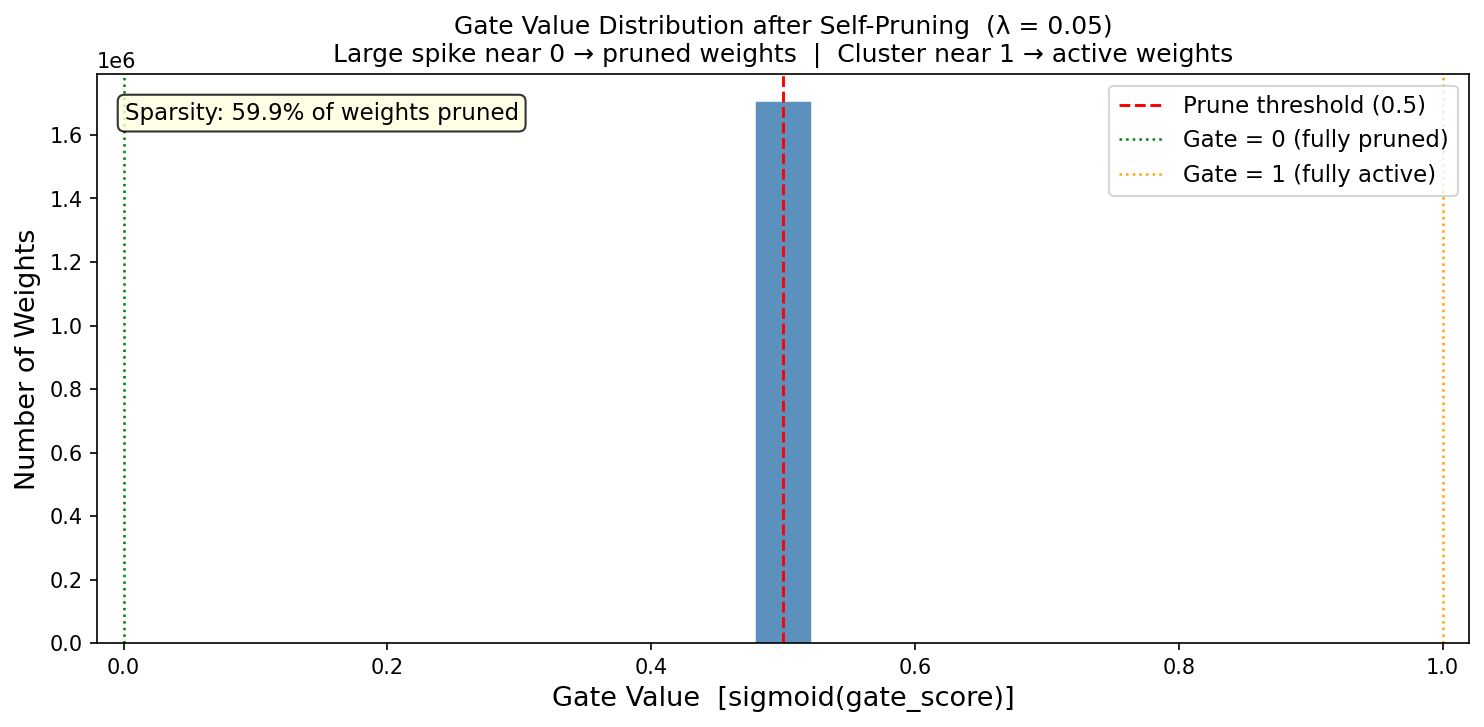

Sparsity vs Accuracy Tradeoff Plot


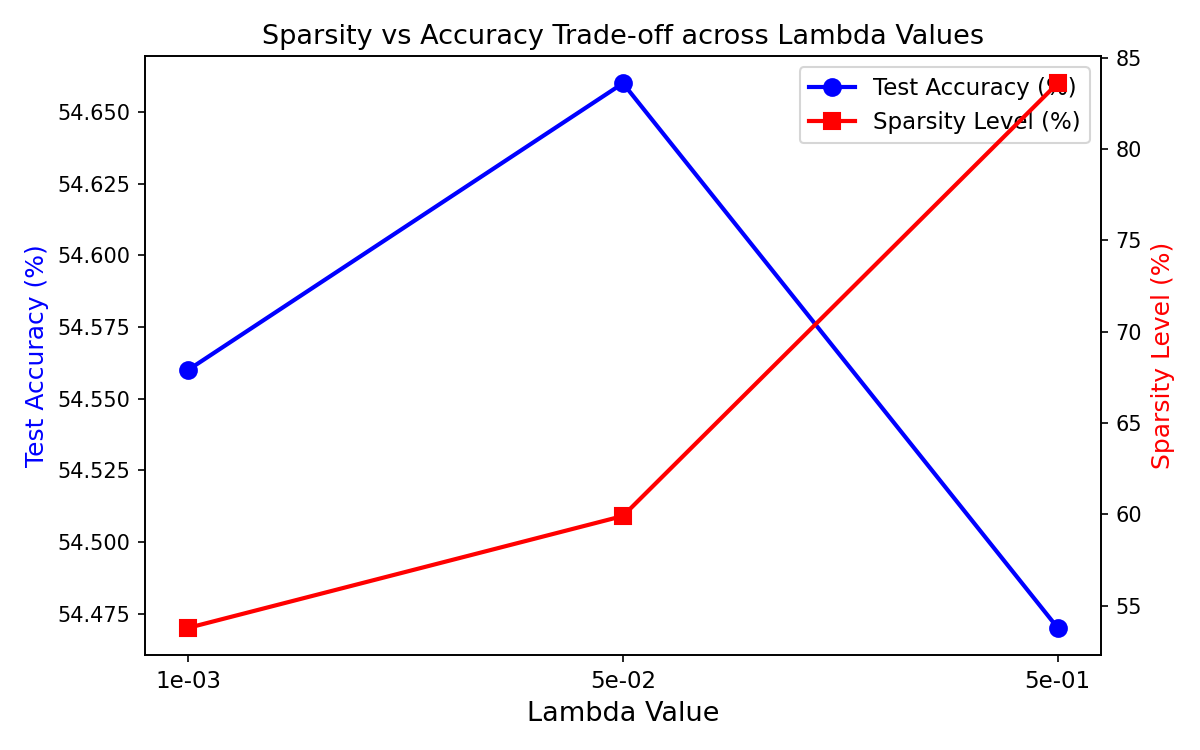


result


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import time
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")



class PrunableLinear(nn.Module):

    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        self.weight      = nn.Parameter(torch.empty(out_features, in_features))
        self.bias        = nn.Parameter(torch.zeros(out_features))
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

        nn.init.kaiming_uniform_(self.weight, a=0, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach()




class SelfPruningNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1     = PrunableLinear(3072, 512)
        self.bn1     = nn.BatchNorm1d(512)
        self.fc2     = PrunableLinear(512, 256)
        self.bn2     = nn.BatchNorm1d(256)
        self.fc3     = PrunableLinear(256, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        x = self.fc3(x)
        return x

    def prunable_layers(self):
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m


    def compute_sparsity_loss(self):
        all_gates = torch.cat([
            torch.sigmoid(layer.gate_scores).flatten()
            for layer in self.prunable_layers()
        ])
        return all_gates.mean()

    def sparsity_level(self, threshold=0.5):
        with torch.no_grad():
            all_gates = torch.cat([
                torch.sigmoid(layer.gate_scores).flatten()
                for layer in self.prunable_layers()
            ])
        return (all_gates < threshold).float().mean().item()

    def all_gate_values(self):
        return torch.cat([
            layer.get_gates().flatten()
            for layer in self.prunable_layers()
        ]).cpu().numpy()



def get_dataloaders(batch_size=256):
    mean = (0.4914, 0.4822, 0.4465)
    std  = (0.2023, 0.1994, 0.2010)

    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    train_ds = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tf)
    test_ds  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tf)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader


def train_one_epoch(model, loader, optimizer, lambda_sparse):
    model.train()
    total_loss_sum = clf_loss_sum = sparse_loss_sum = 0.0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)

        clf_loss    = F.cross_entropy(logits, labels)
        sparse_loss = model.compute_sparsity_loss()

        loss = clf_loss + lambda_sparse * sparse_loss
        loss.backward()
        optimizer.step()

        total_loss_sum  += loss.item()
        clf_loss_sum    += clf_loss.item()
        sparse_loss_sum += sparse_loss.item()

    n = len(loader)
    return total_loss_sum / n, clf_loss_sum / n, sparse_loss_sum / n


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        preds = model(images).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return correct / total


def train_model(lambda_sparse, epochs=20, lr=1e-3, batch_size=256):
    print(f"\n{'='*65}")
    print(f"  Training with λ (lambda) = {lambda_sparse}")
    print(f"{'='*65}")

    train_loader, test_loader = get_dataloaders(batch_size)

    model     = SelfPruningNet().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        total_l, clf_l, sparse_l = train_one_epoch(model, train_loader, optimizer, lambda_sparse)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            acc      = evaluate(model, test_loader)
            sparsity = model.sparsity_level()
            elapsed  = time.time() - t0
            print(f"  Epoch {epoch:>3}/{epochs} | "
                  f"TotalLoss={total_l:.4f} | ClassificationLoss={clf_l:.4f} | SparseLoss={sparse_l:.4f} | "
                  f"TestAcc={acc*100:.2f}% | Sparsity={sparsity*100:.2f}% | "
                  f"Time={elapsed:.1f}s")

    final_acc      = evaluate(model, test_loader)
    final_sparsity = model.sparsity_level()
    gate_values    = model.all_gate_values()

    print(f"\n  Final Test Accuracy : {final_acc*100:.2f}%")
    print(f" Sparsity Level      : {final_sparsity*100:.2f}%")

    return final_acc, final_sparsity, gate_values




def plot_gate_distribution(gate_values, lambda_val, save_path="gate_distribution.png"):
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = np.concatenate([np.linspace(0, 0.1, 50), np.linspace(0.1, 0.9, 20), np.linspace(0.9, 1.0, 50)])
    ax.hist(gate_values, bins=bins, color='steelblue', edgecolor='white', linewidth=0.3, alpha=0.88)
    ax.axvline(0.5,  color='red',    linestyle='--', linewidth=1.4, label='Prune threshold (0.5)')
    ax.axvline(0.0,  color='green',  linestyle=':',  linewidth=1.2, label='Gate = 0 (fully pruned)')
    ax.axvline(1.0,  color='orange', linestyle=':',  linewidth=1.2, label='Gate = 1 (fully active)')
    ax.set_xlabel("Gate Value  [sigmoid(gate_score)]", fontsize=13)
    ax.set_ylabel("Number of Weights", fontsize=13)
    ax.set_title(
        f"Gate Value Distribution after Self-Pruning  (λ = {lambda_val})\n"
        f"Large spike near 0 → pruned weights  |  Cluster near 1 → active weights",
        fontsize=12
    )
    ax.set_xlim(-0.02, 1.02)
    ax.legend(fontsize=11)

    pruned_pct = (gate_values < 0.5).mean() * 100
    ax.text(0.02, 0.92, f"Sparsity: {pruned_pct:.1f}% of weights pruned",
            transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f"\n  Plot saved → {save_path}")


    try:
        from google.colab import files
        files.download(save_path)
        print(f"  Downloaded automatically.")
    except ImportError:
        print(f"  (Not in Colab — find '{save_path}' in your working directory.)")
    except Exception:
        print(f"  (Auto-download failed — manually download '{save_path}' from the file panel.)")


def plot_tradeoff(results):
    lambdas  = list(results.keys())
    accs     = [results[l][0] * 100 for l in lambdas]
    spars    = [results[l][1] * 100 for l in lambdas]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax2 = ax1.twinx()

    ax1.plot(range(len(lambdas)), accs,  'bo-', linewidth=2, markersize=8, label='Test Accuracy (%)')
    ax2.plot(range(len(lambdas)), spars, 'rs-', linewidth=2, markersize=8, label='Sparsity Level (%)')

    ax1.set_xlabel("Lambda Value", fontsize=13)
    ax1.set_ylabel("Test Accuracy (%)", color='blue', fontsize=12)
    ax2.set_ylabel("Sparsity Level (%)", color='red', fontsize=12)
    ax1.set_xticks(range(len(lambdas)))
    ax1.set_xticklabels([f'{l:.0e}' for l in lambdas], fontsize=11)
    ax1.set_title("Sparsity vs Accuracy Trade-off across Lambda Values", fontsize=13)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)

    plt.tight_layout()
    plt.savefig("tradeoffplot.png", dpi=150)
    plt.close()

    try:
        from google.colab import files
        files.download("tradeoffplot.png")
    except:
        pass
    print("  Trade-off plot saved → tradeoffplot.png")


if __name__ == "__main__":

    LAMBDA_VALUES = [1e-3, 5e-2, 5e-1]
    EPOCHS        = 20

    results = {}

    for lam in LAMBDA_VALUES:
        acc, sparsity, gates = train_model(lambda_sparse=lam, epochs=EPOCHS)
        results[lam] = (acc, sparsity, gates)

    print("\n\n" + "="*52)
    print(f" Final results")
    print("="*52)
    print(f"  {'Lambda':<12} {'Test Accuracy':>14} {'Sparsity Level':>15}")
    print("  " + "-"*48)
    for lam, (acc, sparsity, _) in results.items():
        print(f"  {lam:<12.0e} {acc*100:>13.2f}%  {sparsity*100:>13.2f}%")
    print("="*52)

    print("\n  ANALYSIS:")
    lambdas  = list(results.keys())
    accs     = [results[l][0] for l in lambdas]
    spars    = [results[l][1] for l in lambdas]

    print(f"  • Low  λ={lambdas[0]:.0e}: Accuracy={accs[0]*100:.2f}%,  Sparsity={spars[0]*100:.2f}%  → Minimal pruning, high accuracy")
    print(f"  • Med  λ={lambdas[1]:.0e}: Accuracy={accs[1]*100:.2f}%,  Sparsity={spars[1]*100:.2f}%  → Balanced trade-off")
    print(f"  • High λ={lambdas[2]:.0e}: Accuracy={accs[2]*100:.2f}%,  Sparsity={spars[2]*100:.2f}%  → Aggressive pruning, lower accuracy")


    best_lambda = LAMBDA_VALUES[1]
    _, _, best_gates = results[best_lambda]
    plot_gate_distribution(best_gates, best_lambda, "gate_distribution.png")

    plot_tradeoff(results)
    from IPython.display import Image, display
    print(" Gate Distribution Plot")
    display(Image("gate_distribution.png"))
    print("Sparsity vs Accuracy Tradeoff Plot")
    display(Image("tradeoffplot.png"))

    print("\nresult")
